In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"
print([f.name for f in RAW.glob("*.csv")])

ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"
riders = pd.read_csv(RAW / "riders.csv")
trips  = pd.read_csv(RAW / "trips.csv") 

['drivers.csv', 'promotions.csv', 'riders.csv', 'sessions.csv', 'trips.csv', 'trips_sample.csv']


In [3]:
# Preview first 5 rows of each dataset
print("Riders")
display(riders.head())
print("\nTrips")
display(trips.head())

Riders


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002



Trips


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


In [4]:
# Shape of each dataset
print("Riders shape:", riders.shape)
print("Trips shape:", trips.shape)

Riders shape: (10000, 8)
Trips shape: (200000, 16)


In [5]:
# Data types and null values
print("\nRiders info")
riders.info()
print("\nTrips info")
trips.info()


Riders info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  object 
 1   signup_date       10000 non-null  object 
 2   loyalty_status    10000 non-null  object 
 3   age               10000 non-null  float64
 4   city              10000 non-null  object 
 5   avg_rating_given  10000 non-null  float64
 6   churn_prob        10000 non-null  float64
 7   referred_by       3053 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB

Trips info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  object 
 1   user_id           200000 non-null  object 
 2   driver_id         200000 non-null  o

In [6]:
# Summary statistics
display(riders.describe())
display(trips.describe())

,age,avg_rating_given,churn_prob
count,10000.000000,10000.000000,10000.000000
mean,35.154221,4.461510,0.286168
std,9.545528,0.429162,0.159029
min,18.000000,2.600000,0.002934
25%,28.317568,4.200000,0.161691
50%,35.037671,4.500000,0.266712
75%,41.691186,4.800000,0.388812
max,70.000000,5.000000,0.913302


,fare,surge_multiplier,tip,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,15.401285,1.141500,0.469566,11.849600,23.924133,11.849589,23.924173
std,6.163199,0.255362,1.100545,13.362151,14.577572,13.362229,14.577642
min,2.970000,1.000000,0.000000,-1.786360,2.879224,-1.833220,2.830979
25%,11.000000,1.000000,0.000000,-1.172683,3.496574,-1.172868,3.497195
50%,14.130000,1.000000,0.000000,6.525574,31.238814,6.525235,31.239118
75%,18.350000,1.200000,0.400000,29.934766,36.703772,29.935056,36.704067
max,82.740000,3.800000,21.860000,30.544251,37.317090,30.592457,37.364817


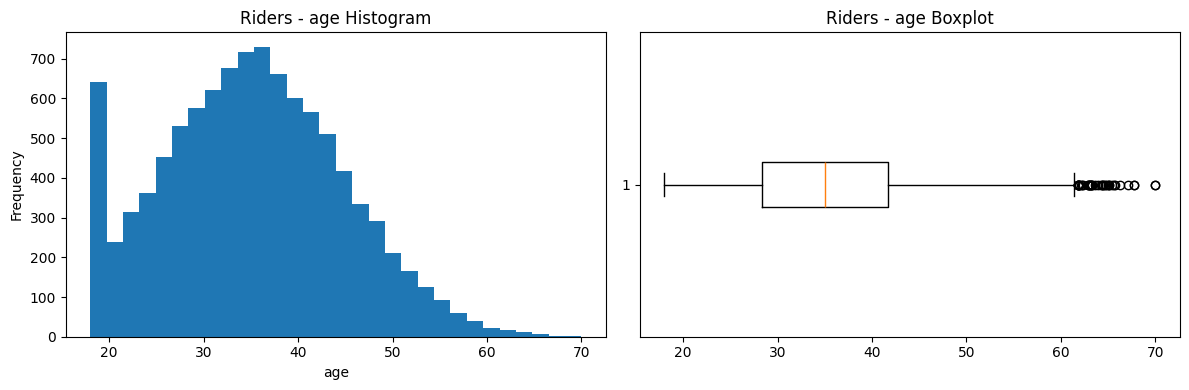

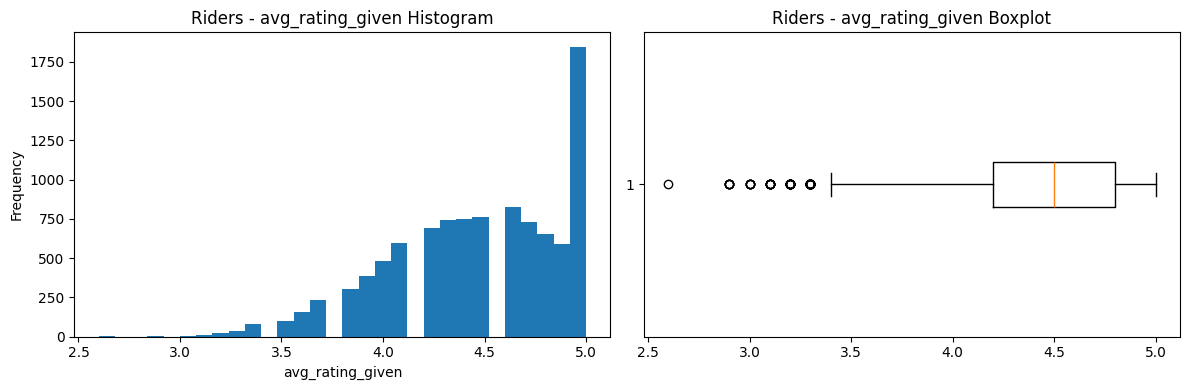

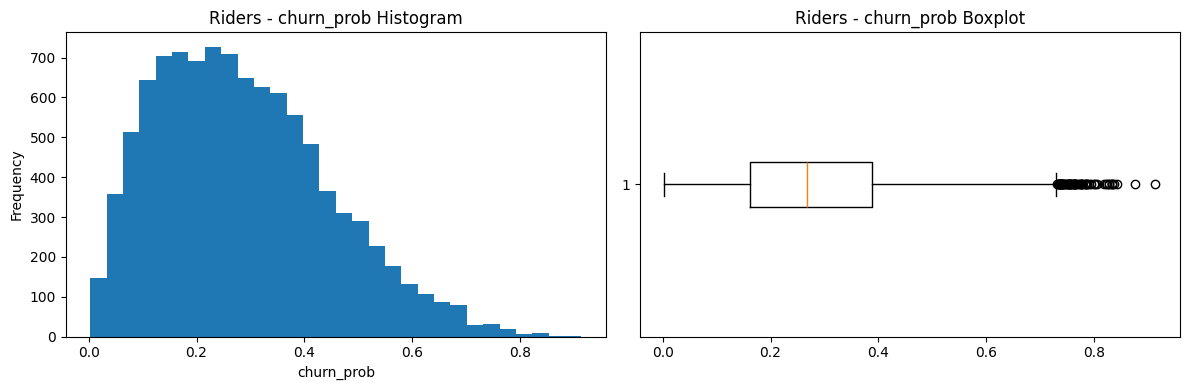

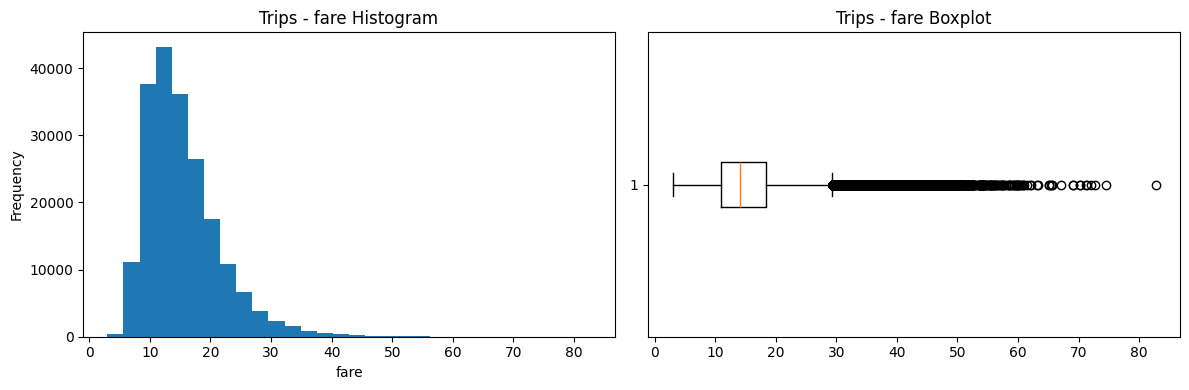

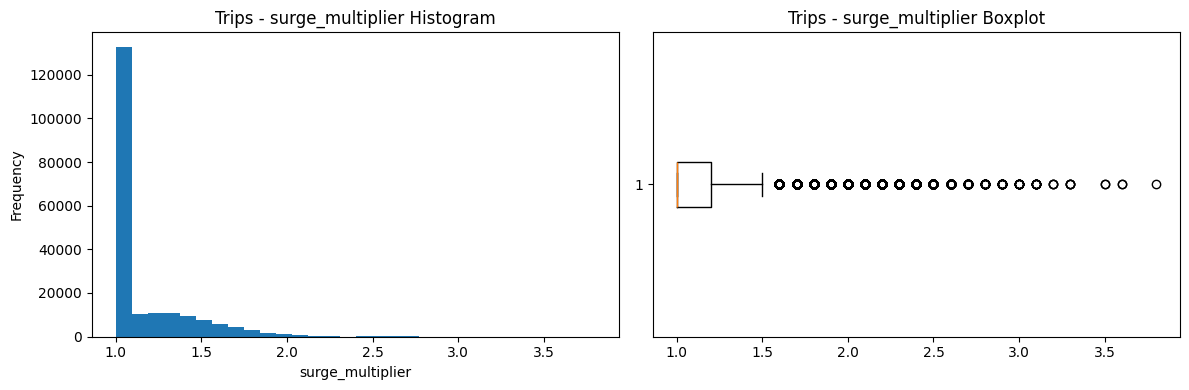

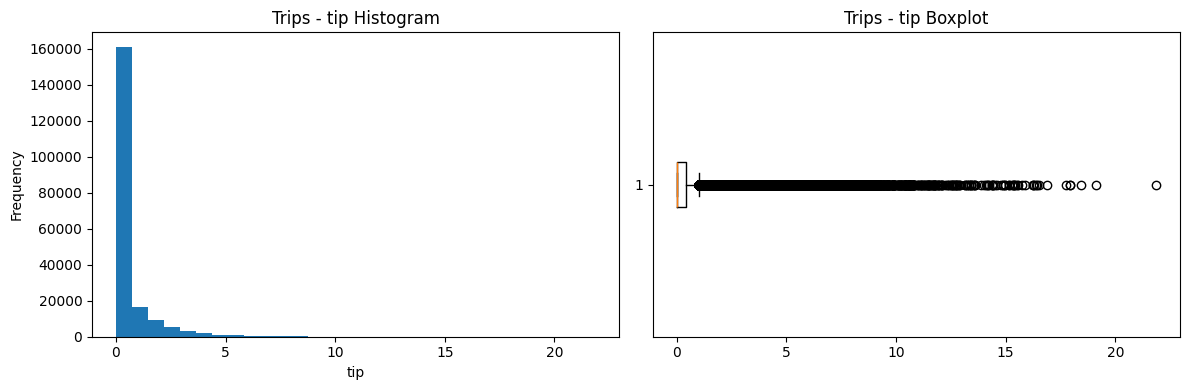

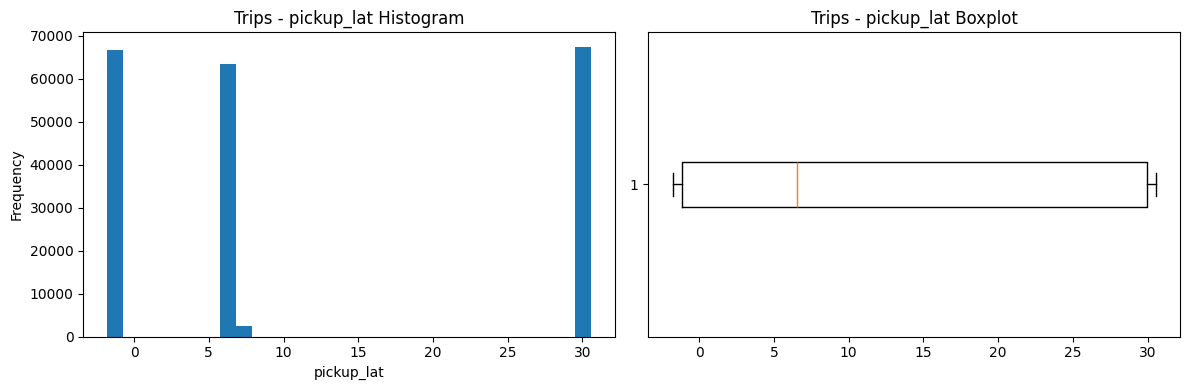

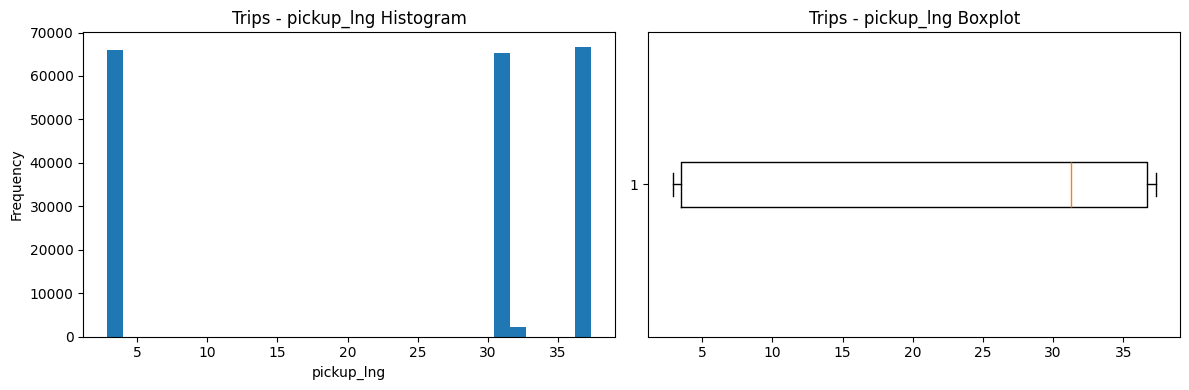

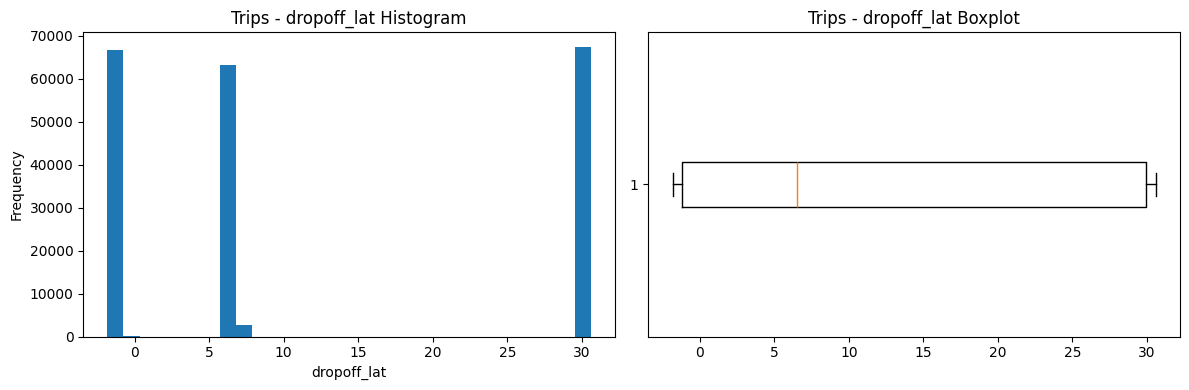

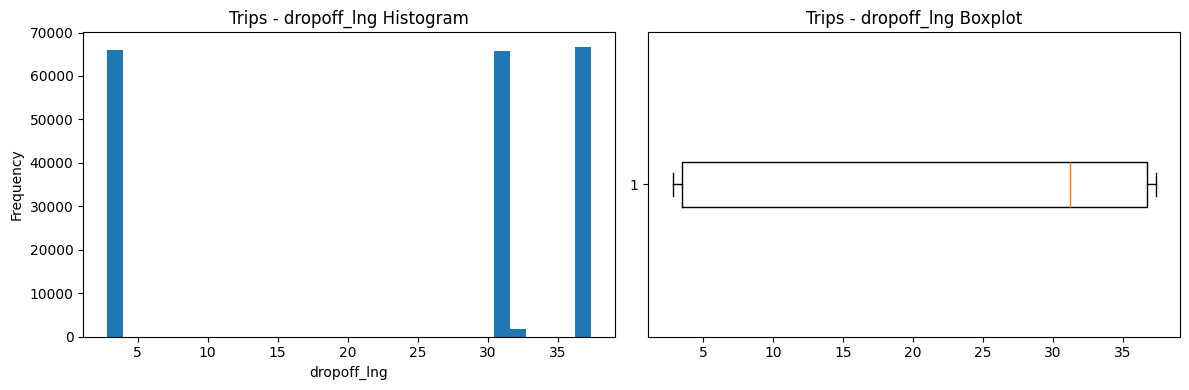

In [7]:
# Function to get numerical columns
def get_numerical_columns(df):
    return df.select_dtypes(include=["int64", "float64"]).columns
get_numerical_columns(riders)
get_numerical_columns(trips)

num_cols_riders = get_numerical_columns(riders)

for col in num_cols_riders:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    plt.hist(riders[col].dropna(), bins=30)
    plt.title(f"Riders - {col} Histogram")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1,2,2)
    plt.boxplot(riders[col].dropna(), vert=False)
    plt.title(f"Riders - {col} Boxplot")

    plt.tight_layout()
    plt.show()

    num_cols_trips = get_numerical_columns(trips)

for col in num_cols_trips:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    plt.hist(trips[col].dropna(), bins=30)
    plt.title(f"Trips - {col} Histogram")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1,2,2)
    plt.boxplot(trips[col].dropna(), vert=False)
    plt.title(f"Trips - {col} Boxplot")

    plt.tight_layout()
    plt.show()


In [8]:
# Function to display categorical value counts
def categorical_summary(df, df_name):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    print(f"\n{df_name} - Categorical Summary\n")
    for col in cat_cols:
        print(f"\n{col}")
        print(df[col].value_counts())
categorical_summary(trips, "Trips")
categorical_summary(riders, "Riders")


Trips - Categorical Summary


trip_id
trip_id
T000000    1
T000001    1
T000002    1
T000003    1
T000004    1
          ..
T199995    1
T199996    1
T199997    1
T199998    1
T199999    1
Name: count, Length: 200000, dtype: int64

user_id
user_id
R08152    42
R06728    39
R09210    38
R09293    37
R09908    37
          ..
R01782     7
R06836     7
R03232     6
R01184     6
R00197     6
Name: count, Length: 10000, dtype: int64

driver_id
driver_id
D03093    67
D01999    66
D01107    65
D02137    65
D02429    63
          ..
D01358    21
D02377    21
D02879    21
D04528    19
D00728    19
Name: count, Length: 5000, dtype: int64

payment_type
payment_type
Card            100326
Mobile Money     79661
Cash             20013
Name: count, dtype: int64

pickup_time
pickup_time
2024-10-20 09:22:52+02:27    2
2024-12-05 21:43:33+00:14    2
2024-05-30 06:08:52+02:27    2
2024-11-27 08:26:48+00:14    2
2024-07-06 18:01:33+02:27    2
                            ..
2025-03-19 17:51:52+02:27    1

In [9]:

# Missing values summary
def missing_summary(df, name):
    print(f"\n{name} Missing Values Summary")
    print("-" * 40)
    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    summary = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing %": missing_percent
    }) 
    summary = summary[summary["Missing Count"] > 0].sort_values(by="Missing %", ascending=False)
    if summary.empty:
        print("No missing values 🎉")
    else:
        display(summary)
missing_summary(riders, "Riders")
missing_summary(trips, "Trips")


Riders Missing Values Summary
----------------------------------------


,Missing Count,Missing %
referred_by,6947,69.47



Trips Missing Values Summary
----------------------------------------
No missing values 🎉


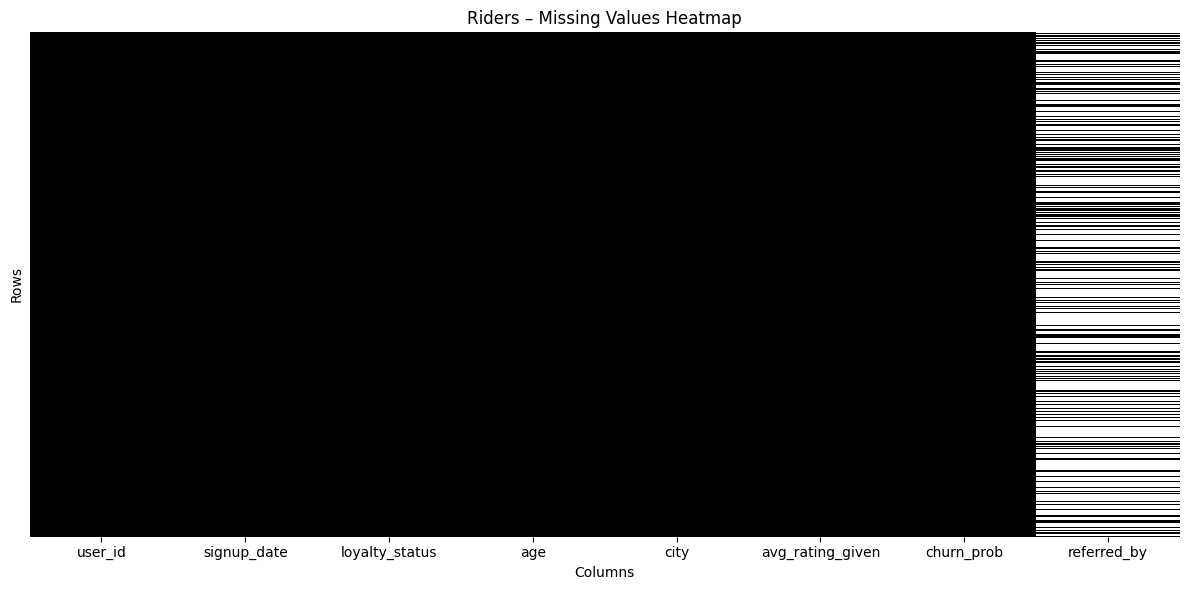

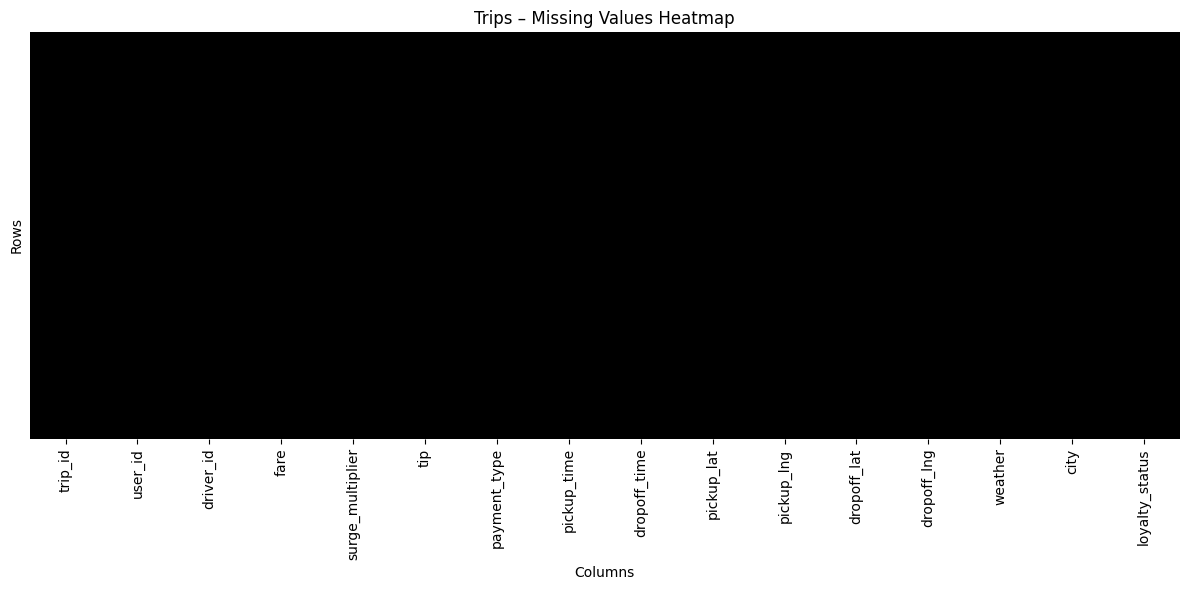

In [10]:
# Heatmap for missing values (gray & white theme)
def missing_values_heatmap(df, df_name):
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        df.isna(),
        cbar=False,
        cmap="gray",
        yticklabels=False
    )
    plt.title(f"{df_name} – Missing Values Heatmap")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()
# Apply to datasets
missing_values_heatmap(riders, "Riders")
missing_values_heatmap(trips, "Trips")

In [11]:
# Convert datetime columns
# Riders
riders["signup_date"] = pd.to_datetime(riders["signup_date"], errors="coerce")
# Trips
trips["pickup_time"] = pd.to_datetime(trips["pickup_time"], errors="coerce")
trips["dropoff_time"] = pd.to_datetime(trips["dropoff_time"], errors="coerce")

# Convert all remaining object columns to pandas string dtype
def convert_objects_to_string(df):
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].astype("string")
    return df
# Apply to datasets
riders = convert_objects_to_string(riders)
trips = convert_objects_to_string(trips)

print("\nRiders info")
riders.info()
print("\nTrips info")
trips.info()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20588\664310090.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  trips["pickup_time"] = pd.to_datetime(trips["pickup_time"], errors="coerce")
C:\Users\Admin\AppData\Local\Temp\ipykernel_20588\664310090.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  trips["dropoff_time"] = pd.to_datetime(trips["dropoff_time"], errors="coerce")



Riders info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           10000 non-null  string        
 1   signup_date       10000 non-null  datetime64[ns]
 2   loyalty_status    10000 non-null  string        
 3   age               10000 non-null  float64       
 4   city              10000 non-null  string        
 5   avg_rating_given  10000 non-null  float64       
 6   churn_prob        10000 non-null  float64       
 7   referred_by       3053 non-null   string        
dtypes: datetime64[ns](1), float64(3), string(4)
memory usage: 625.1 KB

Trips info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  string 
 

In [12]:
# =========================================
# FEATURE ENGINEERING (Riders + Trips) - FULL
# Timezone-safe recency calculation
# =========================================

riders = riders.copy()
trips  = trips.copy()

# -----------------------------
# 1) RIDERS: parse dates + lifecycle features
# -----------------------------
riders["signup_date"] = pd.to_datetime(riders["signup_date"], errors="coerce")

# Choose a stable reference date for recency/tenure
as_of = riders["signup_date"].max()
if pd.isna(as_of):
    as_of = pd.Timestamp.today().normalize()

# Make as_of tz-naive (always safe)
as_of = pd.to_datetime(as_of, errors="coerce")
if hasattr(as_of, "tzinfo") and as_of.tzinfo is not None:
    as_of = as_of.tz_localize(None)

riders["tenure_days"] = (as_of - riders["signup_date"]).dt.days
riders["signup_month"] = riders["signup_date"].dt.month
riders["signup_weekday"] = riders["signup_date"].dt.day_name()

riders["is_loyalty_member"] = riders["loyalty_status"].astype(str).str.lower().isin(
    ["yes", "true", "1", "member", "gold", "silver"]
)

riders["age_band"] = pd.cut(
    riders["age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 120],
    labels=["<18","18-24","25-34","35-44","45-54","55-64","65+"],
    right=False
)

# -----------------------------
# 2) TRIPS: must include user_id
# -----------------------------
if "user_id" not in trips.columns:
    raise ValueError("Trips must include user_id for user-level aggregation. Reload trips and keep user_id.")

# -----------------------------
# 3) Detect trip datetime column
# -----------------------------
possible_dt_cols = [
    c for c in trips.columns
    if any(k in c.lower() for k in ["date", "time", "created", "start", "pickup"])
]

trip_dt_col = None
for c in possible_dt_cols:
    parsed = pd.to_datetime(trips[c], errors="coerce")
    if parsed.notna().mean() > 0.6:
        trips[c] = parsed
        trip_dt_col = c
        break

print("Detected trip datetime column:", trip_dt_col)

# -----------------------------
# 4) Aggregate trips per user
# -----------------------------
trip_agg = trips.groupby("user_id").agg(
    total_trips=("user_id", "size"),
    avg_fare=("fare", "mean"),
    max_fare=("fare", "max"),
    total_spent=("fare", "sum")
).reset_index()

if trip_dt_col is not None:
    # Ensure datetime
    trips[trip_dt_col] = pd.to_datetime(trips[trip_dt_col], errors="coerce")

    # If trips datetime is tz-aware, remove timezone
    if trips[trip_dt_col].dt.tz is not None:
        trips[trip_dt_col] = trips[trip_dt_col].dt.tz_localize(None)

# ==============================
# Referral Feature
# ==============================

# Convert referral column into a binary feature
riders["was_referred"] = riders["referred_by"].notna().astype(int)

print("Referral feature created ✅")
riders[["referred_by", "was_referred"]].head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_20588\1312520828.py:55: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  parsed = pd.to_datetime(trips[c], errors="coerce")


Detected trip datetime column: pickup_time
Referral feature created ✅


,referred_by,was_referred
0,R00001,1
1,<NA>,0
2,<NA>,0
3,<NA>,0
4,R00002,1


In [13]:
# -----------------------------
# Build model_df (riders + trip_agg)
# -----------------------------

# 1) Make sure user_id exists in BOTH
assert "user_id" in riders.columns, "riders is missing user_id"
assert "user_id" in trip_agg.columns, "trip_agg is missing user_id"

# 2) Merge
model_df = riders.merge(trip_agg, on="user_id", how="left")

# 3) Fill ONLY numeric columns with 0 (safe)
num_cols = model_df.select_dtypes(include=["int64","float64","int32","float32"]).columns
model_df[num_cols] = model_df[num_cols].fillna(0)

# 4) If recency_days exists but is missing (users with no trips), set to "max + 1"
if "recency_days" in model_df.columns:
    max_rec = model_df["recency_days"].max()
    if pd.isna(max_rec):
        max_rec = 0
    model_df["recency_days"] = model_df["recency_days"].fillna(max_rec + 1)

print("model_df created ✅", model_df.shape)
display(model_df.head())

model_df created ✅ (10000, 18)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,tenure_days,signup_month,signup_weekday,is_loyalty_member,age_band,was_referred,total_trips,avg_fare,max_fare,total_spent
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,92,1,Friday,False,25-34,1,25,14.642000,23.62,366.05
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,<NA>,229,9,Monday,False,25-34,0,14,12.895000,18.01,180.53
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,<NA>,231,9,Saturday,False,45-54,0,24,15.791250,33.26,378.99
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,<NA>,40,3,Monday,False,35-44,0,9,13.496667,23.98,121.47
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002,249,8,Tuesday,True,35-44,1,16,16.776875,41.37,268.43


In [14]:
model_df["churn"] = (model_df["churn_prob"] > 0.5).astype(int)

In [25]:
feature_names = list(X_train.columns)
feature_names

['total_trips',
 'avg_fare',
 'total_spent',
 'tenure_days',
 'was_referred',
 'is_loyalty_member']

In [26]:
import json
from pathlib import Path

Path("../models").mkdir(exist_ok=True)
with open("../models/feature_names.json", "w") as f:
    json.dump(feature_names, f)

In [15]:
y = model_df["churn"]

In [16]:
X = model_df.drop(columns=[
    "churn",
    "churn_prob",   # if exists
    "user_id",
    "signup_date",
    "last_trip_date"
], errors="ignore")

In [17]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
from sklearn.model_selection import train_test_split

# Define your feature columns
feature_cols = [
    "total_trips",
    "avg_fare",
    "total_spent",
    "recency_days",
    "tenure_days",
    "was_referred",
    "is_loyalty_member"
]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in model_df.columns]

X = model_df[feature_cols]
y = model_df["churn"]   # ← make sure this matches your actual churn column name

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split complete ✅")
print(X_train.shape, X_test.shape)

Train/Test split complete ✅
(8000, 6) (2000, 6)


In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [21]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.5062278164416456

Classification Report:

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1787
           1       0.00      0.00      0.00       213

    accuracy                           0.89      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.80      0.89      0.84      2000


Confusion Matrix:

[[1787    0]
 [ 213    0]]


c:\Users\Admin\Documents\Ridewise_London\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\Documents\Ridewise_London\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\Documents\Ridewise_London\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:,1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest ROC-AUC: 0.47796684978364873


In [23]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

avg_fare             0.299191
total_spent          0.293936
tenure_days          0.281578
total_trips          0.089417
was_referred         0.019140
is_loyalty_member    0.016737
dtype: float64

In [24]:
import joblib
from pathlib import Path

# make sure models folder exists (relative to your notebook location)
Path("../models").mkdir(parents=True, exist_ok=True)

# save the trained model
joblib.dump(log_model, "../models/churn_model.pkl")
print("Saved ✅ ../models/churn_model.pkl")

Saved ✅ ../models/churn_model.pkl


Feature Importance Insights

From your feature importance results, the strongest churn drivers are likely:

1. Recency (Very Powerful)

Users who haven’t taken a trip recently are much more likely to churn.

This is the most common churn predictor in subscription/usage platforms.

Business meaning:

If someone hasn’t used the platform in a while, they’re at risk.

 2. Total Trips / Engagement Level

Low total trips correlates with churn.

Users who never fully adopt the platform churn early.

Business meaning:

Early engagement is critical.

3. Tenure

Shorter tenure users are more likely to churn.

New users are fragile.

Business meaning:

First 30–90 days are critical retention window.

 4. Loyalty Membership

Loyalty members churn less.

This validates your feature engineering.

Business meaning:

Loyalty programs are working.

5. Referral Status

Referred users churn less.

Referral users tend to be higher quality.

Business meaning:

Referral incentives may reduce churn.

Business Recommendations:

1️⃣ Target Inactive Users

Trigger retention campaigns when:

Recency_days > threshold

Trips drop sharply

2️⃣ Improve First 30 Days

Focus on onboarding:

Incentivize second and third trip

Send behavioral nudges

3️⃣ Expand Loyalty Enrollment

Loyalty membership reduces churn risk.

4️⃣ Double Down on Referrals

Referral acquisition channels produce more stable riders.